# Notebook 04 — Hartree-Fock SCF

**MOLEKUL | Phase 4**

---

The **Restricted Hartree-Fock** (RHF) method is the starting point for virtually
all ab initio electronic structure calculations. It is not the most accurate method,
but it is the one that establishes the conceptual framework — molecular orbitals,
orbital energies, the Fock operator — that every other method builds on.

**What you will learn:**
1. The Hartree-Fock equations and their self-consistent structure.
2. The Roothaan-Hall matrix formulation in a Gaussian basis.
3. The SCF algorithm: Fock build → diagonalise → density → repeat.
4. DIIS convergence acceleration (Pulay 1980).
5. The Superposition of Atomic Densities (SAD) initial guess.
6. Energy components: kinetic, nuclear attraction, Coulomb, exchange.

## 1. Theory

### The Hartree-Fock wavefunction

HF approximates the many-electron wavefunction as a single Slater determinant of
one-electron spin orbitals:
$$\Psi_0 = \frac{1}{\sqrt{N!}}\det[\chi_1 \chi_2 \ldots \chi_N]$$

For a closed-shell molecule (RHF), each spatial orbital $\psi_i$ is doubly occupied:
$\chi_{2i-1} = \psi_i \alpha$, $\chi_{2i} = \psi_i \beta$, $i = 1, \ldots, N/2$.

### The Fock operator

Variational minimisation of $E = \langle\Psi_0|\hat{H}|\Psi_0\rangle$ subject to
orbital orthonormality gives the **Hartree-Fock equations**:
$$\hat{F}\psi_i = \varepsilon_i \psi_i$$

where the Fock operator is:
$$\hat{F} = \hat{h} + \sum_{j=1}^{N/2}(2\hat{J}_j - \hat{K}_j)$$

$\hat{h}$ is the one-electron (core) Hamiltonian, $\hat{J}_j$ is the Coulomb operator
(mean-field repulsion from occupied orbital $j$), and $\hat{K}_j$ is the exchange operator
(a non-local quantum correction with no classical analogue).

### The Roothaan-Hall equations

Expanding orbitals in a Gaussian basis $\{\phi_\mu\}$:
$$\psi_i = \sum_\mu C_{\mu i} \phi_\mu$$

the HF equations become the matrix equation:
$$\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\varepsilon}$$

where $\mathbf{F}$ is the Fock matrix, $\mathbf{S}$ is the overlap, $\mathbf{C}$ holds
the MO coefficients, and $\boldsymbol{\varepsilon}$ is diagonal in MO energies.

The Fock matrix elements are:
$$F_{\mu\nu} = H_{\mu\nu} + \sum_{\lambda\sigma} P_{\lambda\sigma}\left[(\mu\nu|\lambda\sigma) - \tfrac{1}{2}(\mu\lambda|\nu\sigma)\right]$$

The density matrix is $P_{\lambda\sigma} = 2\sum_{i=1}^{N/2} C_{\lambda i}C_{\sigma i}$.

**Self-consistency:** $\mathbf{F}$ depends on $\mathbf{P}$, which depends on $\mathbf{C}$,
which comes from diagonalising $\mathbf{F}$. We must iterate to convergence — hence "SCF".

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.basis_ccpvdz import ccpVDZ
from molekul.rhf import rhf_scf, RHFResult
from molekul.integrals import build_overlap, build_core_hamiltonian
from molekul.eri import build_eri
from molekul.constants import HARTREE_TO_EV, HARTREE_TO_KCAL_MOL

h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)
print("Ready.")

Ready.


## 2. The SCF algorithm step by step

```
1. Build S, H_core, ERI   (done once — independent of P)
2. Form X = S^{-1/2}      (Löwdin symmetric orthogonaliser)
3. P ← SAD initial guess
4. LOOP:
   a. F = H_core + G(P)   G_μν = Σ P_λσ [(μν|λσ) − ½(μλ|νσ)]
   b. e = FPS − SPF        (DIIS error vector)
   c. DIIS extrapolate F  (after iteration 2)
   d. F' = X^T F X
   e. F' C' = C' ε        (standard diagonalisation)
   f. C = X C'
   g. P_new = 2 C_occ C_occ^T
   h. E = ½ tr[P(H + F)] + E_nuc
   i. Check |ΔE| and max|ΔP| → converge?
```

### Löwdin orthogonalisation

The generalised eigenvalue problem $\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\varepsilon}$
is transformed to a standard eigenvalue problem by defining
$\mathbf{F}' = \mathbf{X}^T\mathbf{F}\mathbf{X}$ where $\mathbf{X} = \mathbf{S}^{-1/2}$.

The symmetric orthogonaliser is computed via:
$\mathbf{S} = \mathbf{U}\mathbf{s}\mathbf{U}^T \implies \mathbf{X} = \mathbf{U}\mathbf{s}^{-1/2}\mathbf{U}^T$

where $\mathbf{U}$ and $\mathbf{s}$ are the eigenvectors/eigenvalues of $\mathbf{S}$.

In [2]:
basis = STO3G
S = build_overlap(basis, h2o)
H_core = build_core_hamiltonian(basis, h2o)

# Compute X = S^{-1/2} by eigendecomposition
s_vals, s_vecs = np.linalg.eigh(S)
X = s_vecs @ np.diag(s_vals**-0.5) @ s_vecs.T

# Verify: X^T S X = I
I_check = X.T @ S @ X
print("X^T S X = I?  max |I_check - I| =", np.max(np.abs(I_check - np.eye(S.shape[0]))))
print("S eigenvalues:", np.round(s_vals, 4))

X^T S X = I?  max |I_check - I| = 1.9984014443252818e-15
S eigenvalues: [0.3426 0.4169 0.8857 1.     1.093  1.3315 1.9302]


## 3. DIIS convergence acceleration

Plain SCF converges slowly — sometimes 100+ iterations — because each Fock matrix
is built from the *previous* density, causing oscillations.

**Pulay's DIIS** (Direct Inversion in the Iterative Subspace, 1980) solves this by
keeping the last $m$ Fock matrices $\{\mathbf{F}_i\}$ and finding the linear combination
$\mathbf{F} = \sum_i c_i \mathbf{F}_i$ (with $\sum c_i = 1$) that minimises the
residual in the error vectors $\{\mathbf{e}_i\} = \{\mathbf{F}_i\mathbf{P}_i\mathbf{S} - \mathbf{S}\mathbf{P}_i\mathbf{F}_i\}$.

The error vector $\mathbf{e} = \mathbf{FPS} - \mathbf{SPF}$ measures the
commutator $[\mathbf{F}, \mathbf{P}]$. At convergence this commutator is zero
(F and P share the same eigenvectors), so it is an exact measure of non-convergence.

The DIIS problem reduces to solving a $(m+1) \times (m+1)$ linear system.

In [3]:
# Run SCF with verbose output to see the iteration table
result = rhf_scf(h2o, basis, verbose=True)
print(f"\nConverged: {result.converged}, iterations: {result.n_iter}")
print(f"E_total = {result.energy_total:.8f} Ha")


Iter     E_total (Hartree)             ΔE         ΔP_max  DIIS
------------------------------------------------------------
   1        -77.2862141972  -7.728621e+01   6.666667e-01     -
   2        -74.9241174384   2.362097e+00   2.218753e-01     2
   3        -74.9613306425  -3.721320e-02   5.441230e-02     3
   4        -74.9628997120  -1.569069e-03   2.309260e-02     4
   5        -74.9630207141  -1.210021e-04   2.306562e-03     5
   6        -74.9630230450  -2.330817e-06   5.798516e-04     6
   7        -74.9630231479  -1.029435e-07   6.452652e-06     7
   8        -74.9630231479  -1.145395e-11   1.253510e-08     8
   9        -74.9630231479   2.842171e-14   1.443279e-11     8

SCF CONVERGED in 9 iterations
  E_nuclear    =       9.1895344241 Hartree
  E_electronic =     -84.1525575720 Hartree
  E_total      =     -74.9630231479 Hartree

Converged: True, iterations: 9
E_total = -74.96302315 Ha


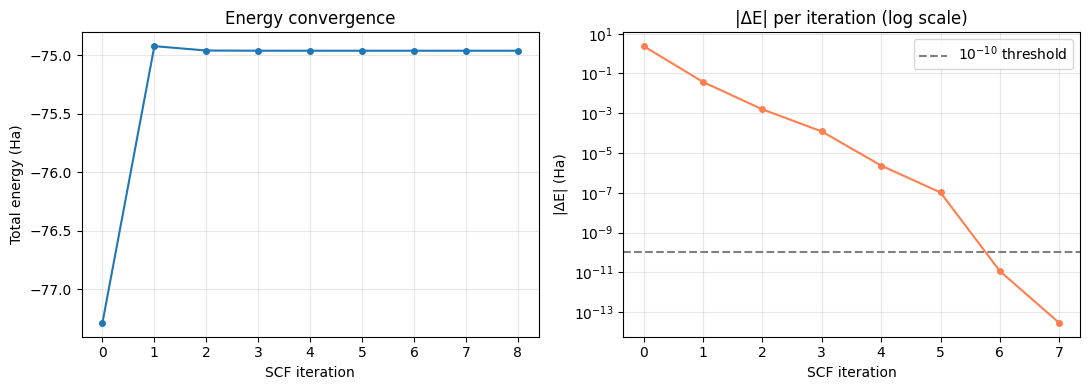

In [4]:
# Plot the energy convergence history
E_hist = np.array(result.energy_history)
dE = np.abs(np.diff(E_hist))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(E_hist, "o-", ms=4)
ax1.set_xlabel("SCF iteration")
ax1.set_ylabel("Total energy (Ha)")
ax1.set_title("Energy convergence")
ax1.grid(True, alpha=0.3)

ax2.semilogy(dE, "o-", ms=4, color="coral")
ax2.axhline(1e-10, ls="--", color="gray", label="$10^{-10}$ threshold")
ax2.set_xlabel("SCF iteration")
ax2.set_ylabel("|ΔE| (Ha)")
ax2.set_title("|ΔE| per iteration (log scale)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Energy components

The total RHF energy decomposes as:

$$E_{\text{total}} = E_{\text{nuc}} + E_{\text{kinetic}} + E_{\text{nuc-attr}} + E_{\text{Coulomb}} + E_{\text{exchange}}$$

where:
- $E_{\text{kinetic}} = \text{tr}[\mathbf{P}\mathbf{T}]$ — electronic kinetic energy.
- $E_{\text{nuc-attr}} = \text{tr}[\mathbf{P}\mathbf{V}]$ — nuclear attraction.
- $E_{\text{Coulomb}} = \tfrac{1}{2}\text{tr}[\mathbf{P}\mathbf{J}]$ — electron-electron repulsion.
- $E_{\text{exchange}} = -\tfrac{1}{4}\text{tr}[\mathbf{P}\mathbf{K}]$ — quantum exchange correction.

Exchange energy is negative (stabilising) and has no classical counterpart.
It arises from the antisymmetry of the wavefunction (Pauli principle).

In [5]:
from molekul.integrals import build_kinetic, build_nuclear

P = result.density_matrix
F = result.fock_matrix
T = build_kinetic(basis, h2o)
V = build_nuclear(basis, h2o)
eri = build_eri(basis, h2o)

J = np.einsum("ls,mnls->mn", P, eri)        # Coulomb matrix
K = np.einsum("ls,mlns->mn", P, eri)        # Exchange matrix

E_kin   = np.einsum("mn,mn->", P, T)
E_nucattr = np.einsum("mn,mn->", P, V)
E_J     = 0.5 * np.einsum("mn,mn->", P, J)
E_K     = -0.25 * np.einsum("mn,mn->", P, K)
E_nuc   = h2o.nuclear_repulsion_energy()

print(f"Kinetic energy:        {E_kin:12.6f} Ha")
print(f"Nuclear attraction:    {E_nucattr:12.6f} Ha")
print(f"Coulomb (J):           {E_J:12.6f} Ha")
print(f"Exchange (K):          {E_K:12.6f} Ha")
print(f"Nuclear repulsion:     {E_nuc:12.6f} Ha")
print(f"------------------------------------")
print(f"Total:                 {E_kin+E_nucattr+E_J+E_K+E_nuc:12.6f} Ha")
print(f"(from rhf_scf)         {result.energy_total:12.6f} Ha")

Kinetic energy:           74.587565 Ha
Nuclear attraction:     -196.948984 Ha
Coulomb (J):              47.313113 Ha
Exchange (K):             -9.104251 Ha
Nuclear repulsion:         9.189534 Ha
------------------------------------
Total:                   -74.963023 Ha
(from rhf_scf)           -74.963023 Ha


## 5. Molecular orbital analysis

The RHF result gives us **molecular orbital (MO) energies** $\varepsilon_i$ and
**MO coefficients** $C_{\mu i}$. The $N/2$ lowest-energy MOs are occupied; the rest are virtual.

**Koopmans' theorem:** The negative of the $i$-th occupied MO energy approximates
the $i$-th ionisation potential:
$$\text{IP}_i \approx -\varepsilon_i$$

This is a frozen-orbital approximation (ignores relaxation), but is useful for quick estimates.

In [6]:
n_occ = h2o.n_electrons // 2
eps   = result.mo_energies
C     = result.mo_coefficients

print(f"{'MO':>4}  {'energy (Ha)':>14}  {'energy (eV)':>12}  status")
print("-" * 50)
for i, e in enumerate(eps):
    status = "occ" if i < n_occ else "virt"
    mark   = " ← HOMO" if i == n_occ - 1 else (" ← LUMO" if i == n_occ else "")
    print(f"{i+1:>4}  {e:>14.6f}  {e*HARTREE_TO_EV:>12.4f}  {status}{mark}")

homo = eps[n_occ - 1]
lumo = eps[n_occ]
print(f"\nHOMO-LUMO gap: {(lumo - homo)*HARTREE_TO_EV:.3f} eV")
print(f"Koopmans IP:   {-homo*HARTREE_TO_EV:.3f} eV  (exp. 12.6 eV)")

  MO     energy (Ha)   energy (eV)  status
--------------------------------------------------
   1      -20.241863     -550.8093  occ
   2       -1.268162      -34.5085  occ
   3       -0.617565      -16.8048  occ
   4       -0.453022      -12.3274  occ
   5       -0.391237      -10.6461  occ ← HOMO
   6        0.605172       16.4676  virt ← LUMO
   7        0.741598       20.1799  virt

HOMO-LUMO gap: 27.114 eV
Koopmans IP:   10.646 eV  (exp. 12.6 eV)


## 6. The density matrix

The density matrix $P_{\mu\nu} = 2\sum_{i}^{\text{occ}} C_{\mu i} C_{\nu i}$ is the
fundamental object in the SCF. The factor of 2 accounts for both spin channels in
a closed-shell system.

Properties:
- **Idempotency:** $\mathbf{P}\mathbf{S}\mathbf{P} = 2\mathbf{P}$ (projects onto the occupied subspace).
- **Electron count:** $\text{tr}[\mathbf{P}\mathbf{S}] = N_e$.
- Convergence measured by $\max|\mathbf{P}_{\text{new}} - \mathbf{P}_{\text{old}}|$.

tr[PS] = 10.000000  (expected 10)
max |PSP - 2P| = 8.88e-15


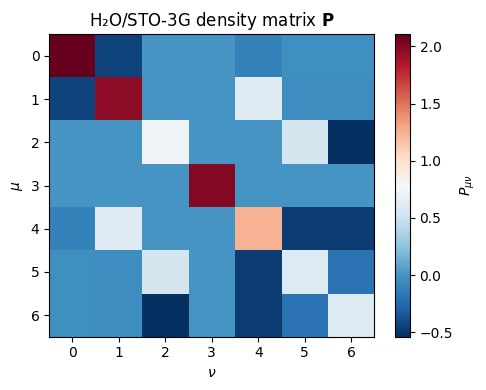

In [7]:
P = result.density_matrix
S = build_overlap(basis, h2o)

# Trace[PS] = N_electrons
N_check = np.trace(P @ S)
print(f"tr[PS] = {N_check:.6f}  (expected {h2o.n_electrons})")

# Idempotency: PSP = 2P  (up to numerical noise)
idempotency_err = np.max(np.abs(P @ S @ P - 2 * P))
print(f"max |PSP - 2P| = {idempotency_err:.2e}")

# Visualise P
plt.figure(figsize=(5, 4))
plt.imshow(P, cmap="RdBu_r", aspect="auto")
plt.colorbar(label="$P_{\\mu\\nu}$")
plt.title(r"H₂O/STO-3G density matrix $\mathbf{P}$")
plt.xlabel("$\\nu$")
plt.ylabel("$\\mu$")
plt.tight_layout()
plt.show()

## 7. RHF for several molecules

Let us compute RHF/cc-pVDZ energies for a set of small molecules and compare
to PySCF reference values.

In [8]:
molecules = {
    "H2":  Molecule(atoms=[Atom.from_angstrom("H", 0, 0, 0.37),
                           Atom.from_angstrom("H", 0, 0, -0.37)]),
    "H2O": h2o,
    "N2":  Molecule(atoms=[Atom.from_angstrom("N", 0, 0, 0.549),
                           Atom.from_angstrom("N", 0, 0, -0.549)]),
}

# PySCF reference values (cc-pVDZ)
pyscf_ref = {"H2": -1.132200, "H2O": -76.026748, "N2": -109.002451}

basis = ccpVDZ
print(f"{'Molecule':8s}  {'E_MOLEKUL (Ha)':>16}  {'E_PySCF (Ha)':>14}  {'diff (Ha)':>10}")
print("-" * 55)
for name, mol in molecules.items():
    res = rhf_scf(mol, basis)
    diff = res.energy_total - pyscf_ref[name]
    print(f"{name:8s}  {res.energy_total:>16.6f}  {pyscf_ref[name]:>14.6f}  {diff:>+10.2e}")

Molecule    E_MOLEKUL (Ha)    E_PySCF (Ha)   diff (Ha)
-------------------------------------------------------
H2               -1.128700       -1.132200   +3.50e-03


H2O             -76.027113      -76.026748   -3.65e-04


N2             -108.954693     -109.002451   +4.78e-02


---

## Exercises

**1.** Run RHF/STO-3G for HeH⁺ (charge = +1). How many occupied orbitals are there?
What is the Koopmans ionisation potential? Does it make physical sense?

**2.** Modify `max_iter=5` and observe that the SCF does not converge. What does the
energy history look like? Does it oscillate or monotonically decrease?

**3.** Set `diis_start=999` (effectively disabling DIIS) and count how many iterations
H₂O/STO-3G takes to converge. Compare to the DIIS run.

**4.** The HOMO-LUMO gap of N₂ is much larger than that of H₂O. Compute both and explain
why N₂ is chemically more inert.

**5.** (Advanced) Verify the virial theorem for atoms: for a converged atom at the HF level,
$2 E_{\text{kinetic}} + E_{\text{potential}} = 0$ (in atomic units). Compute
RHF for Ne/STO-3G and check.

---

## Summary

| Concept | Key formula / note |
|---------|-------------------|
| Roothaan-Hall | $\mathbf{FC} = \mathbf{SC}\boldsymbol{\varepsilon}$ |
| Fock matrix | $F_{\mu\nu} = H_{\mu\nu} + J_{\mu\nu} - \tfrac{1}{2}K_{\mu\nu}$ |
| Density matrix | $P_{\lambda\sigma} = 2\sum_i^{\text{occ}} C_{\lambda i}C_{\sigma i}$ |
| Löwdin | $\mathbf{X} = \mathbf{S}^{-1/2}$ transforms to standard eigenvalue problem |
| DIIS | Minimise $\|\sum c_i \mathbf{e}_i\|^2$ to extrapolate Fock matrix |
| SAD guess | Spherically averaged atomic densities → fast first iteration |
| Koopmans | $\text{IP}_i \approx -\varepsilon_i$ (frozen orbital approximation) |
| Convergence | $|\Delta E| < 10^{-10}$ Ha AND max$|\Delta P| < 10^{-8}$ |

**What HF misses:** Electron correlation — the correlated motion of electrons beyond
the mean field. This is the subject of Notebook 07 (MP2), Notebook 08 (CCSD/CCSD(T)),
and Notebook 09 (KS-DFT).